In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv(r"D:\SMART COACH\dataset\passenger_detail.csv")
print(df.head())

   id  passenger_name  age       gender  train_no booking_type       source  \
0   1    Nert Spitell   54       Female     84471       Direct        Salem   
1   2   Lelah Manston   76  Genderfluid     75255       Tatkal   Coimbatore   
2   3  Lodovico Dicke   36         Male     88415      Counter  Tirunelveli   
3   4  Ruperta Talloe   16       Female     96439       Online      Chennai   
4   5  Daveen Wakeley   37  Genderfluid     80648       Direct  Tirunelveli   

  destination coach  seat_no  fare travel_date ticket_status  
0     Madurai    A2       53   224   1/17/2026     Confirmed  
1     Chennai    B1       41  2102    9/1/2018       Waiting  
2       Salem    S1       29  2117   3/26/2025           RAC  
3      Trichy    A1       52  1932   3/10/2019       Waiting  
4      Trichy    D1       24   713   7/25/2020     Cancelled  


In [5]:
df = df.drop(columns=['passenger_name'])

In [6]:
encoder = LabelEncoder()

cols = [
    'gender',
    'booking_type',
    'ticket_status',
    'source',
    'destination',
    'coach'
]

for col in cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   id  age  gender  train_no  booking_type  source  destination  coach  \
0   1   54       2     84471             1       6            5      1   
1   2   76       3     75255             3       2            1      2   
2   3   36       5     88415             0       7            6      4   
3   4   16       2     96439             2       1            8      0   
4   5   37       3     80648             1       7            8      3   

   seat_no  fare travel_date  ticket_status  
0       53   224   1/17/2026              1  
1       41  2102    9/1/2018              3  
2       29  2117   3/26/2025              2  
3       52  1932   3/10/2019              3  
4       24   713   7/25/2020              0  


In [7]:
X = df[[
    'age',
    'gender',
    'source',
    'destination',
    'fare',
    'ticket_status'
]]
y = df['booking_type']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print("Railway Logistic Model Trained")

Railway Logistic Model Trained


In [11]:
score = model.score(X_test, y_test)
print("Accuracy:", score)

Accuracy: 0.29


In [12]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[2 3 0 0 0 0 2 2 1 1]


In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 4 12  7 18]
 [11 16  6 25]
 [10 11 10 22]
 [11  4  5 28]]


In [17]:
print("classification Report:")
print(classification_report(y_test, y_pred))

classification Report:
              precision    recall  f1-score   support

           0       0.11      0.10      0.10        41
           1       0.37      0.28      0.32        58
           2       0.36      0.19      0.25        53
           3       0.30      0.58      0.40        48

    accuracy                           0.29       200
   macro avg       0.29      0.29      0.27       200
weighted avg       0.30      0.29      0.27       200



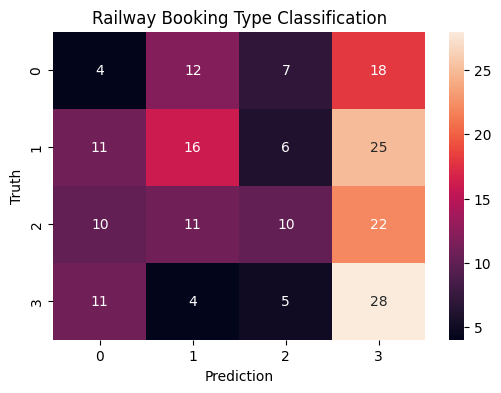

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True)
plt.title("Railway Booking Type Classification")
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()